In [2]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
df = pd.read_csv('/content/retailmax.csv')

In [ ]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
type(scaled_features)

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [ ]:
clusters

In [ ]:
len(clusters)

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [ ]:
clusters

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [ ]:
clusters

In [ ]:
df

In [ ]:
df['clasificación'] = clusters
df

In [ ]:
df['clasificación'].value_counts()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='clasificación', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

In [ ]:
    # Función para calcular la Suma de Cuadrados Dentro del Cluster (WCSS)
def calcular_wcss(datos):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)
    return wcss

# Calcular el WCSS para diferentes números de clusters
wcss = calcular_wcss(scaled_features)

# Graficar el método del codo
plt.plot(range(1, 11), wcss)
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

In [7]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [8]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:3]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298]])

In [9]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_features)

clusters

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [10]:
df["Cluster"] = clusters

df.sample(5, random_state=42)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
95,96,Male,24,60,52,1
15,16,Male,22,20,79,1
30,31,Male,60,30,4,0
158,159,Male,34,78,1,3
128,129,Male,59,71,11,3


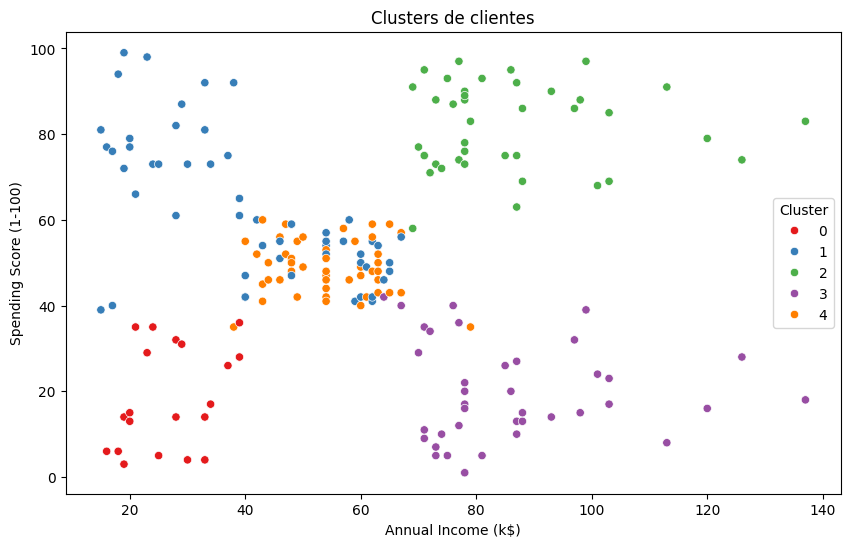

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1'
)

plt.title('Clusters de clientes')
plt.show()

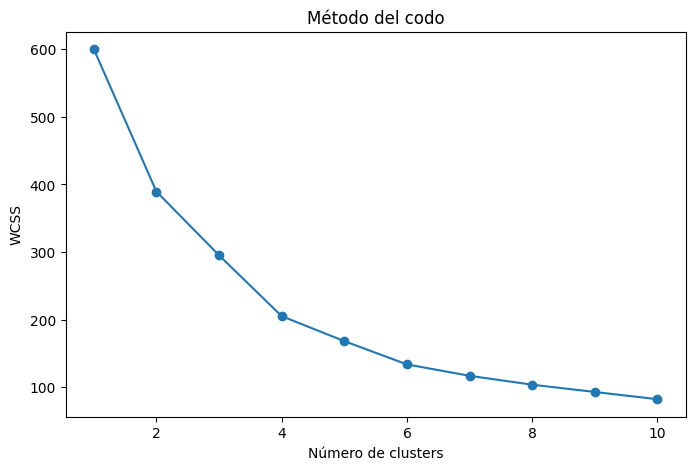

In [12]:
def calcular_wcss(datos):
    wcss = []

    for n in range(1, 11):
        kmeans = KMeans(
            n_clusters=n,
            init='k-means++',
            max_iter=300,
            n_init=10,
            random_state=42
        )

        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)

    return wcss


wcss = calcular_wcss(scaled_features)


plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')

plt.show()

In [13]:
cluster_analysis = df[
    [
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)',
        'Cluster'
    ]
].groupby('Cluster').mean()

cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [14]:
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad promedio: {cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual promedio: {cluster_analysis['Annual Income (k$)'][cluster]:.2f} k$")
    print(f" - Spending Score promedio: {cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print("===================================")

Cluster 0:
 - Edad promedio: 46.25
 - Ingreso anual promedio: 26.75 k$
 - Spending Score promedio: 18.35
Cluster 1:
 - Edad promedio: 25.19
 - Ingreso anual promedio: 41.09 k$
 - Spending Score promedio: 62.24
Cluster 2:
 - Edad promedio: 32.88
 - Ingreso anual promedio: 86.10 k$
 - Spending Score promedio: 81.53
Cluster 3:
 - Edad promedio: 39.87
 - Ingreso anual promedio: 86.10 k$
 - Spending Score promedio: 19.36
Cluster 4:
 - Edad promedio: 55.64
 - Ingreso anual promedio: 54.38 k$
 - Spending Score promedio: 48.85


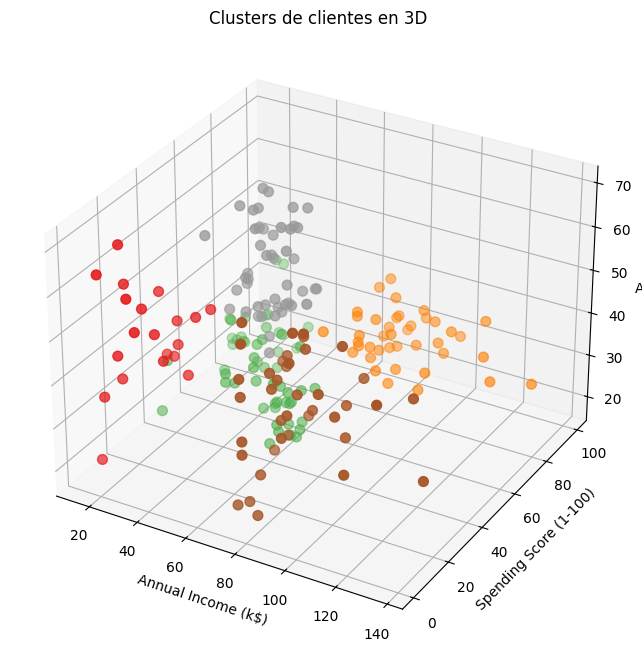

In [16]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    df['Age'],
    c=df['Cluster'],
    cmap='Set1',
    s=50
)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')

ax.set_title('Clusters de clientes en 3D')

plt.show()

In [17]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters

In [18]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [19]:
cluster_analysis = df[['Age',
                       'Annual Income (k$)',
                       'Spending Score (1-100)',
                       'Cluster']].groupby('Cluster').mean()

cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [20]:
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad promedio: {cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual promedio: {cluster_analysis['Annual Income (k$)'][cluster]:.2f} k$")
    print(f" - Spending Score promedio: {cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print("===================================")

Cluster 0:
 - Edad promedio: 46.25
 - Ingreso anual promedio: 26.75 k$
 - Spending Score promedio: 18.35
Cluster 1:
 - Edad promedio: 25.19
 - Ingreso anual promedio: 41.09 k$
 - Spending Score promedio: 62.24
Cluster 2:
 - Edad promedio: 32.88
 - Ingreso anual promedio: 86.10 k$
 - Spending Score promedio: 81.53
Cluster 3:
 - Edad promedio: 39.87
 - Ingreso anual promedio: 86.10 k$
 - Spending Score promedio: 19.36
Cluster 4:
 - Edad promedio: 55.64
 - Ingreso anual promedio: 54.38 k$
 - Spending Score promedio: 48.85
